# Import libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Data Exploration:

Data Dictionary (column description)
- Gender: Gender of the student (male/female)
- EthnicGroup: Ethnic group of the student (group A to E)
- ParentEduc: Parent(s) education background (from some_highschool to master's degree)
- LunchType: School lunch type (standard or free/reduced)
- TestPrep: Test preparation course followed (completed or none)
- ParentMaritalStatus: Parent(s) marital status (married/single/widowed/divorced)
- PracticeSport: How often the student parctice sport (never/sometimes/regularly))
- IsFirstChild: If the child is first child in the family or not (yes/no)
- NrSiblings: Number of siblings the student has (0 to 7)
- TransportMeans: Means of transport to school (schoolbus/private)
- WklyStudyHours: Weekly self-study hours(less that 5hrs; between 5 and 10hrs; more than 10hrs)
- MathScore: math test score(0-100)
- ReadingScore: reading test score(0-100)
- WritingScore: writing test score(0-100)

**1. Dataset Exploration:**

  **• Load the dataset and explore its structure.**

  **• Identify the target variable and potential features for linear regression.**

1. Problem Definition & Understanding

In [2]:
df = pd.read_csv("/content/Expanded_data_with_more_features.csv")
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [3]:
df.drop("Unnamed: 0" , axis=1 , inplace=True)

In [4]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


1. problem type => regression
2. target variables => MathScore	ReadingScore	WritingScore( create 3 models to predict each score)
3. potential features => ParentEduc, TestPrep,	WklyStudyHours

2. Data Understanding



·	 Inspect the dataset


In [5]:
#Number of rows and columns
df.shape

(30641, 14)

In [6]:
#Column names
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings',
       'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore',
       'WritingScore'],
      dtype='object')

In [7]:
#Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


In [8]:
#Basic statistics
df.describe()

,NrSiblings,MathScore,ReadingScore,WritingScore
count,29069.000000,30641.000000,30641.000000,30641.000000
mean,2.145894,66.558402,69.377533,68.418622
std,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,10.000000,4.000000
25%,1.000000,56.000000,59.000000,58.000000
50%,2.000000,67.000000,70.000000,69.000000
75%,3.000000,78.000000,80.000000,79.000000
max,7.000000,100.000000,100.000000,100.000000




*   Understand each feature



In [9]:
"""
o	Numerical

  1.   NrSiblings => has null

  2. for marks cols there might be few outliers below the lower boundry

"""

'\no\tNumerical\n\n  1.   NrSiblings => has null\n\n  2. for marks cols there might be few outliers below the lower boundry\n\n'

In [10]:
#categorical
cats = ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild',
       'TransportMeans', 'WklyStudyHours']

In [11]:
for cat in cats:
  print(df[cat].value_counts())
  print("")

Gender
female    15424
male      15217
Name: count, dtype: int64

EthnicGroup
group C    9212
group D    7503
group B    5826
group E    4041
group A    2219
Name: count, dtype: int64

ParentEduc
some college          6633
high school           5687
associate's degree    5550
some high school      5517
bachelor's degree     3386
master's degree       2023
Name: count, dtype: int64

LunchType
standard        19905
free/reduced    10736
Name: count, dtype: int64

TestPrep
none         18856
completed     9955
Name: count, dtype: int64

ParentMaritalStatus
married     16844
single       7097
divorced     4919
widowed       591
Name: count, dtype: int64

PracticeSport
sometimes    15213
regularly    10793
never         4004
Name: count, dtype: int64

IsFirstChild
yes    19082
no     10655
Name: count, dtype: int64

TransportMeans
school_bus    16145
private       11362
Name: count, dtype: int64

WklyStudyHours
5 - 10    16246
< 5        8238
> 10       5202
Name: count, dtype: int64



In [12]:
"""
o	Categorical
  1. 'Gender' => binary
  2.'EthnicGroup'=> norminal
  3.'ParentEduc', => norminal
  4.'LunchType', => binary
  6.'TestPrep', => binary
  7.'ParentMaritalStatus', => norminal
  8.'PracticeSport', => ordinal: regularly -> sometimes -> never
  9.'IsFirstChild', => binary
  10'TransportMeans' => binary
  11.'WklyStudyHours' => ordinal: > 10 -> 5 - 10 -> < 5

binary=['Gender','LunchType','TestPrep','IsFirstChild','TransportMeans']
norminal =['EthnicGroup','ParentEduc','ParentMaritalStatus']
ordinal = {
  'PracticeSport' : ["regularly" , "sometimes" , "never" ],
  'WklyStudyHours' : [ "10" , "5 - 10" , "< 5" ]
}
"""

'\no\tCategorical\n  1. \'Gender\' => binary\n  2.\'EthnicGroup\'=> norminal\n  3.\'ParentEduc\', => norminal\n  4.\'LunchType\', => binary\n  6.\'TestPrep\', => binary\n  7.\'ParentMaritalStatus\', => norminal\n  8.\'PracticeSport\', => ordinal: regularly -> sometimes -> never\n  9.\'IsFirstChild\', => binary\n  10\'TransportMeans\' => binary\n  11.\'WklyStudyHours\' => ordinal: > 10 -> 5 - 10 -> < 5\n\nbinary=[\'Gender\',\'LunchType\',\'TestPrep\',\'IsFirstChild\',\'TransportMeans\']\nnorminal =[\'EthnicGroup\',\'ParentEduc\',\'ParentMaritalStatus\']\nordinal = {\n  \'PracticeSport\' : ["regularly" , "sometimes" , "never" ],\n  \'WklyStudyHours\' : [ "10" , "5 - 10" , "< 5" ]\n}\n'

##2. Data Wrangling & Cleaning

###• Handle missing values: Decide on an appropriate strategy (imputation, removal, etc.).

In [13]:
df.isna().sum()

,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572
TransportMeans,3134


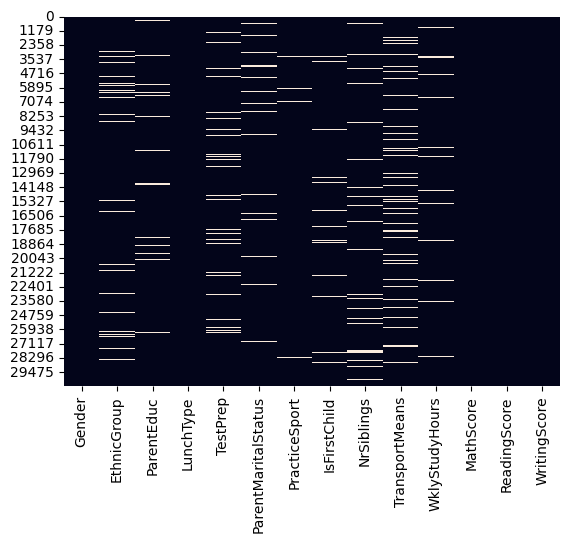

In [14]:
sns.heatmap(df.isna(),cbar=False)
plt.show()

In [15]:
"""
there is no overlaying in the null values between cols
"""

'\nthere is no overlaying in the null values between cols\n'

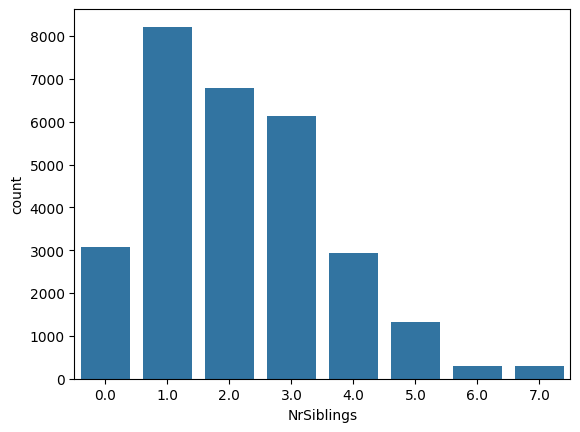

In [16]:
sns.countplot(data=df, x='NrSiblings')
plt.show()

In [17]:
df['NrSiblings'].fillna(int(df['NrSiblings'].median()), inplace=True)

/tmp/ipykernel_908/76486715.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NrSiblings'].fillna(int(df['NrSiblings'].median()), inplace=True)


In [18]:
df['NrSiblings'] = df['NrSiblings'].astype(int)

In [19]:
df.isna().sum()

,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,0
TransportMeans,3134


In [20]:
cats = ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild',
       'TransportMeans', 'WklyStudyHours']
len(cats)

10

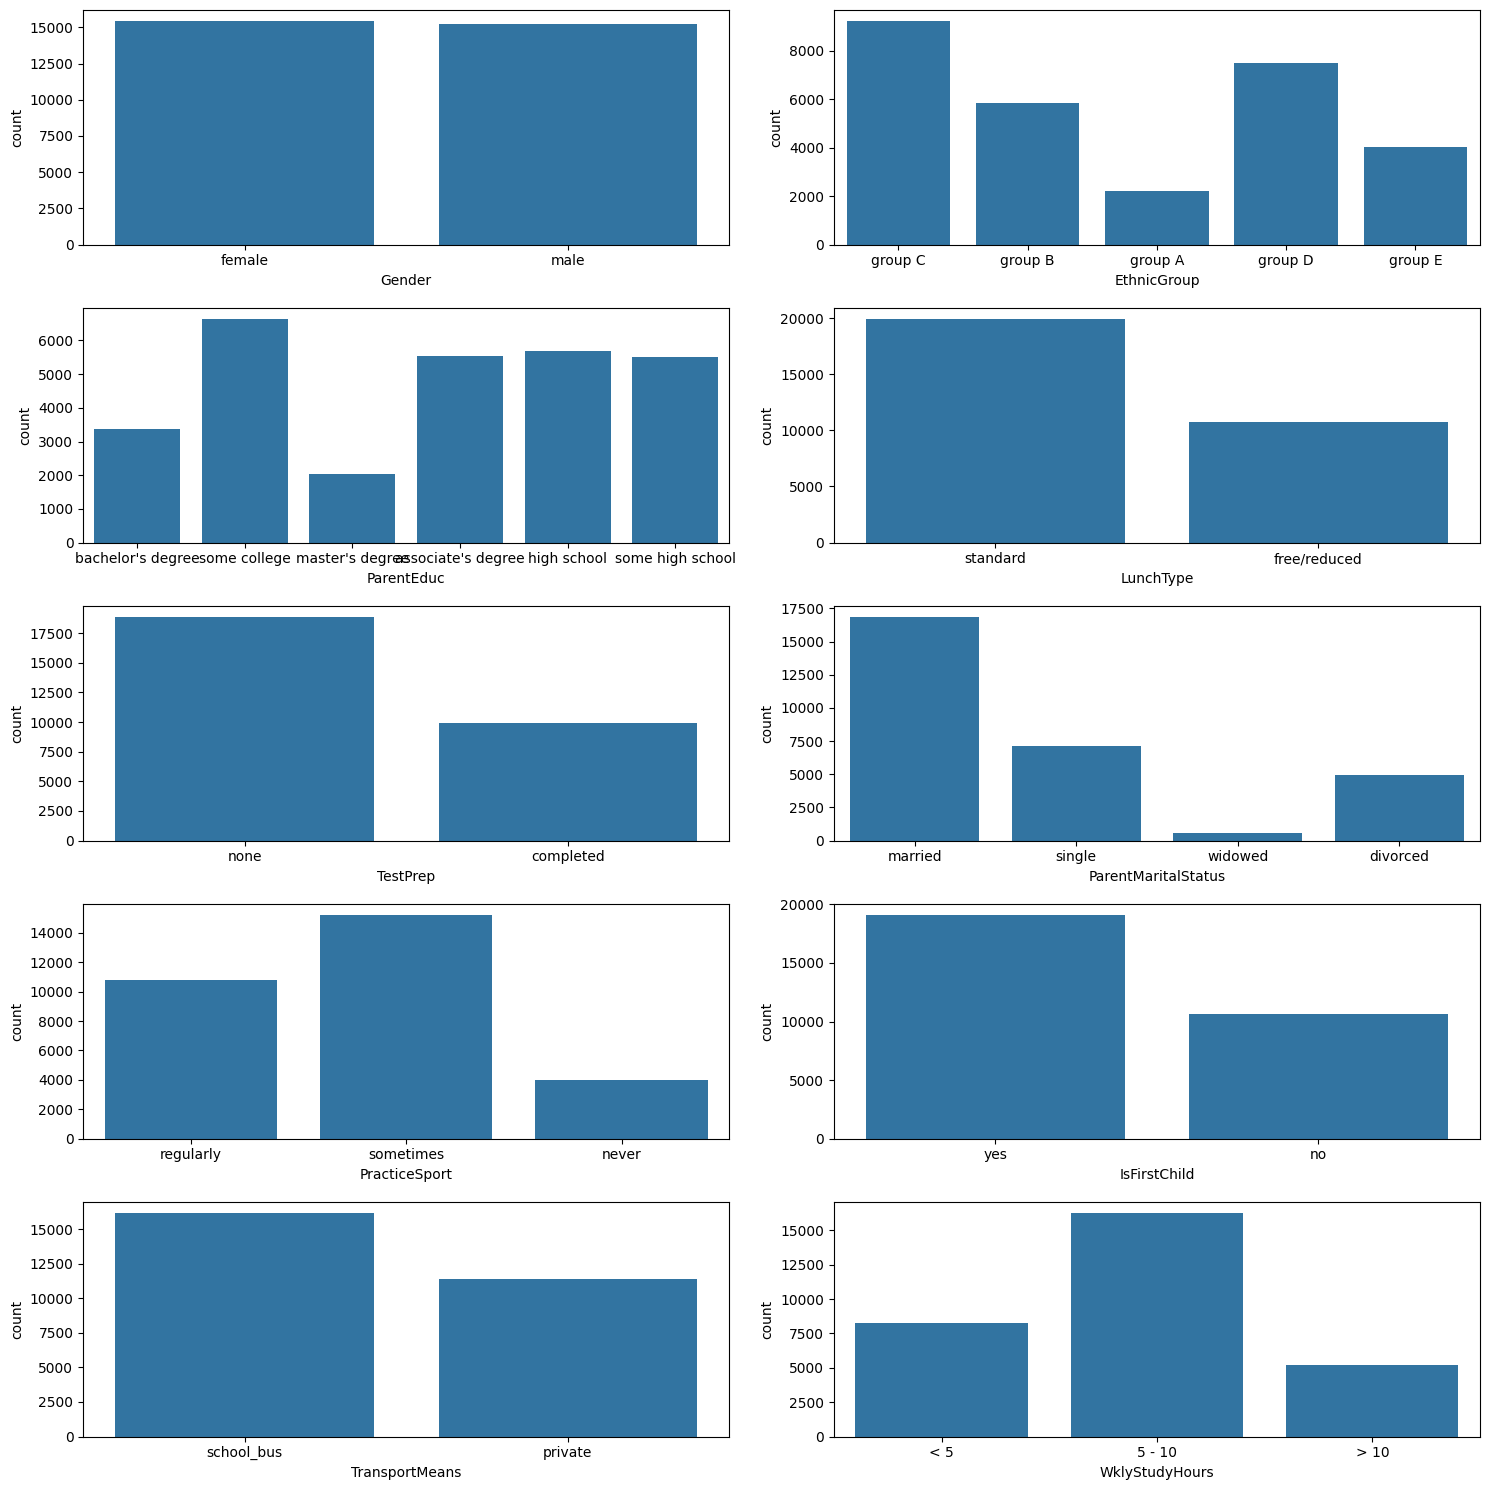

In [21]:
fig = plt.figure(figsize=(15,15))

for i,cat in enumerate(cats,start=1):
  fig.add_subplot(5,2,i)
  sns.countplot(data=df,x=cat)

plt.tight_layout()
plt.show()


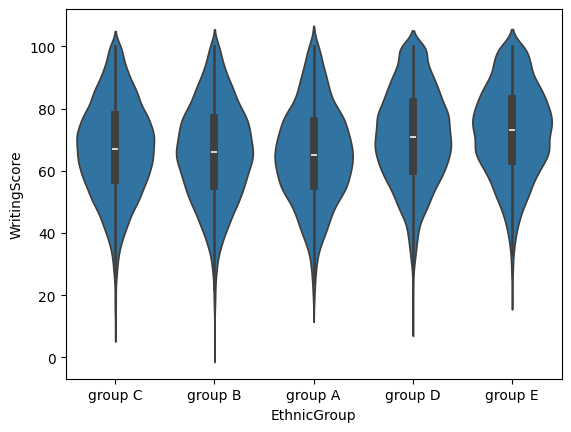

In [22]:
sns.violinplot(data=df,x="EthnicGroup" , y='WritingScore')
plt.show()


In [23]:
df.fillna({'EthnicGroup':"group U" , 'ParentEduc' : "Unknown" , 'ParentMaritalStatus' : "Unknown" }, inplace=True) #maybe they are orphans

In [24]:
# df.drop("EthnicGroup",axis=1,inplace=True)

In [25]:
df.fillna({'WklyStudyHours' : df['WklyStudyHours'].mode()[0]},inplace=True)

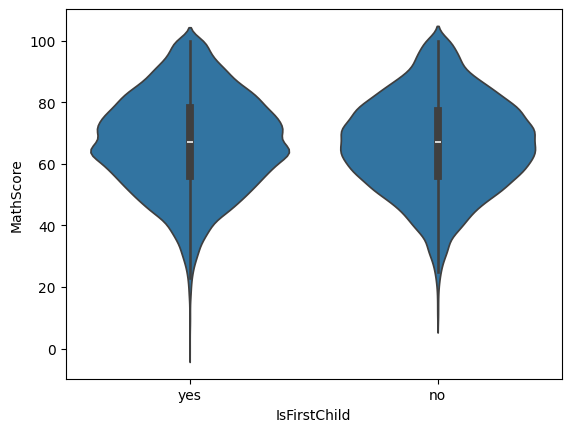

In [26]:
sns.violinplot(data=df,x="IsFirstChild" , y='MathScore')
plt.show()


In [27]:
df.drop("IsFirstChild",axis=1,inplace=True)

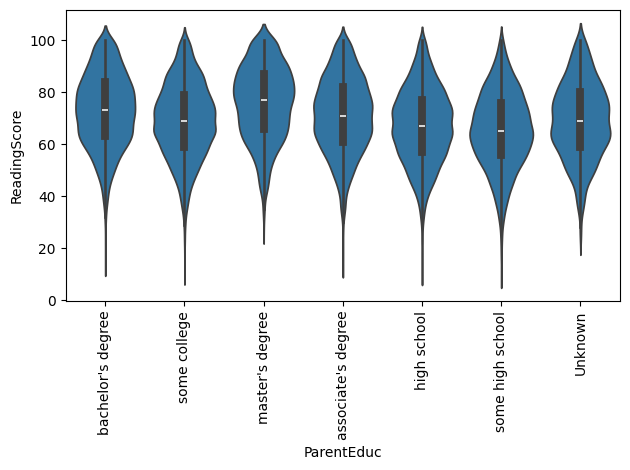

In [28]:
sns.violinplot(data=df,x="ParentEduc" , y='ReadingScore')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [29]:
# df.drop("ParentEduc",axis=1,inplace=True)

In [30]:
# df.drop(['TransportMeans','PracticeSport','ParentMaritalStatus','ParentEduc'], axis=1,inplace=True)

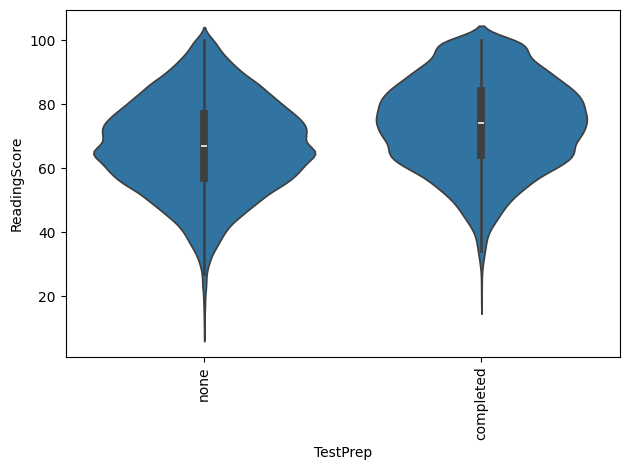

In [31]:
sns.violinplot(data=df,x="TestPrep" , y='ReadingScore')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [32]:
df.dropna(subset="TestPrep",inplace=True)

In [33]:
df.isna().mean()* 100

,0
Gender,0.000000
EthnicGroup,0.000000
ParentEduc,0.000000
LunchType,0.000000
TestPrep,0.000000
ParentMaritalStatus,0.000000
PracticeSport,2.075596
NrSiblings,0.000000
TransportMeans,10.159314
WklyStudyHours,0.000000


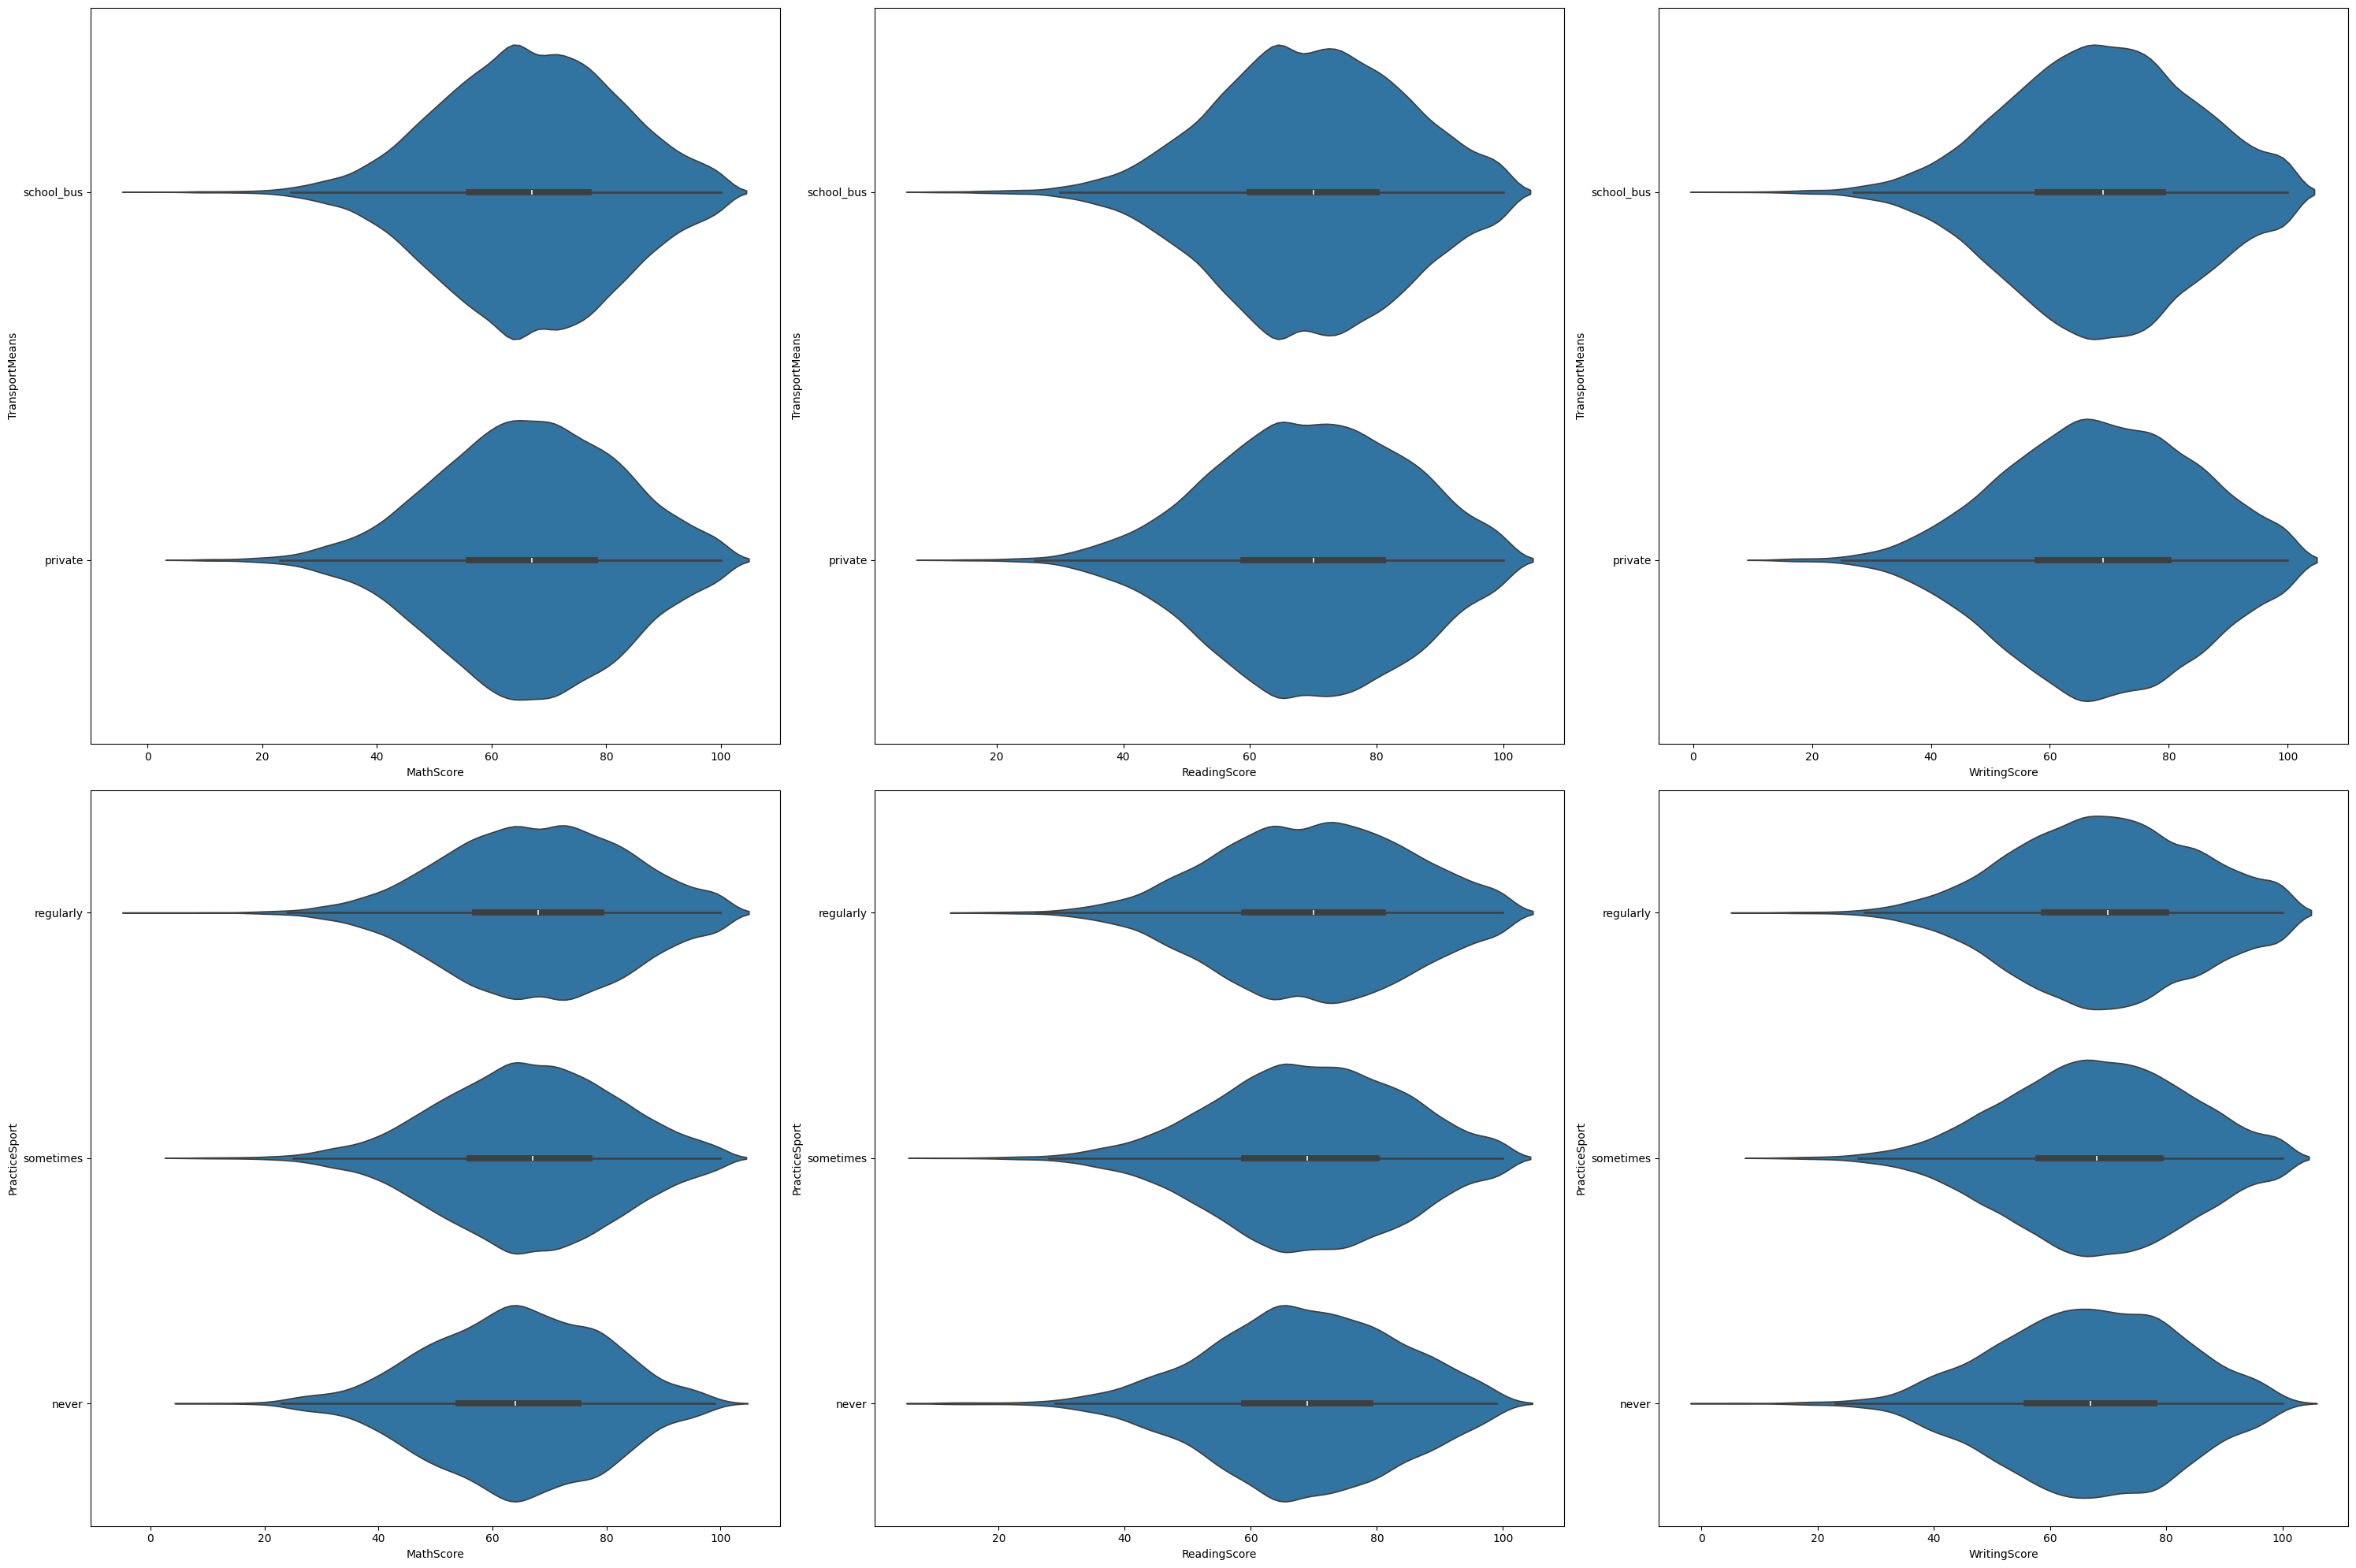

In [34]:
subjects = ['MathScore','ReadingScore','WritingScore'] #cols
cats = ['TransportMeans','PracticeSport'] #rows

fig,axes = plt.subplots(2,3,figsize=(30,20))
for i,cat in enumerate(cats):
  for j,sub in enumerate(subjects):
    sns.violinplot(data= df , x=sub , y=cat , ax=axes[i,j])

plt.tight_layout()
plt.show()


In [35]:
df.drop(['TransportMeans','PracticeSport'], axis=1,inplace=True)

In [36]:
df.isna().sum()

,0
Gender,0
EthnicGroup,0
ParentEduc,0
LunchType,0
TestPrep,0
ParentMaritalStatus,0
NrSiblings,0
WklyStudyHours,0
MathScore,0
ReadingScore,0


In [37]:
#duplicates
df.duplicated().sum()

np.int64(6)

In [38]:
df.shape

(28811, 11)

In [40]:
11/28811

0.00038179861858318005

In [41]:
df.drop_duplicates(inplace=True)

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.shape

(28805, 11)

In [44]:
# df[df['TestPrep'].isna() & df['WklyStudyHours'].isna()].shape

In [45]:
#drop when both are null WklyStudyHours and TestPrep
#df = df.dropna(subset=['WklyStudyHours' , 'TestPrep'] , how='all')

In [46]:
#df = df.dropna(subset=['WklyStudyHours' , 'TestPrep'] , how='any')

###• Explore and address outliers if present.

In [47]:
def outliers(df,col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  loweer_bounder = Q1 - 1.5 * IQR
  upper_bounder = Q3 + 1.5 * IQR
  return (loweer_bounder , upper_bounder , df[(df[col]< loweer_bounder) | (df[col]> upper_bounder) ])


In [206]:
siblingLow , siblingHigh , siblingOutiers =  outliers(df,"NrSiblings")
siblingOutiers.count() # I will not drop it because it is an actual value

,0
Gender,279
EthnicGroup,279
ParentEduc,279
TestPrep,279
ParentMaritalStatus,279
NrSiblings,279
WklyStudyHours,279
MathScore,279
ReadingScore,279
WritingScore,279


In [205]:
df[df['NrSiblings'] == 0].count()

,0
Gender,2894
EthnicGroup,2894
ParentEduc,2894
TestPrep,2894
ParentMaritalStatus,2894
NrSiblings,2894
WklyStudyHours,2894
MathScore,2894
ReadingScore,2894
WritingScore,2894


In [48]:
mathLow, mathUpper , matheOutliers = outliers(df,"MathScore")
matheOutliers.count()

,0
Gender,106
EthnicGroup,106
ParentEduc,106
LunchType,106
TestPrep,106
ParentMaritalStatus,106
NrSiblings,106
WklyStudyHours,106
MathScore,106
ReadingScore,106


In [49]:
readLow, readUpper , readeOutliers = outliers(df,"ReadingScore")
readeOutliers.count()

,0
Gender,87
EthnicGroup,87
ParentEduc,87
LunchType,87
TestPrep,87
ParentMaritalStatus,87
NrSiblings,87
WklyStudyHours,87
MathScore,87
ReadingScore,87


In [50]:
writeLow, writeUpper , writeOutliers = outliers(df,"WritingScore")
writeOutliers.count()

,0
Gender,105
EthnicGroup,105
ParentEduc,105
LunchType,105
TestPrep,105
ParentMaritalStatus,105
NrSiblings,105
WklyStudyHours,105
MathScore,105
ReadingScore,105


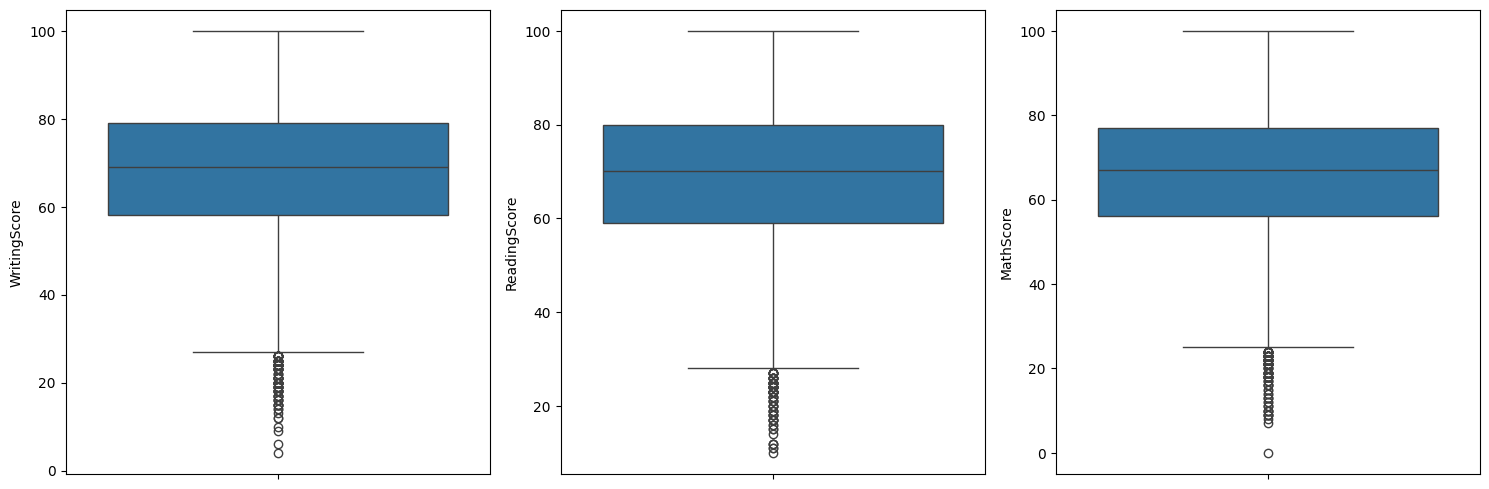

In [51]:
cols = ['WritingScore', 'ReadingScore' , 'MathScore']
fig = plt.figure(figsize=(15,5))
for i,col in enumerate(cols , start=1):
  fig.add_subplot(1,3,i)
  sns.boxplot(data=df , y=col)
plt.tight_layout()
plt.show()

In [52]:
df[(df['WritingScore']<writeLow) & (df['ReadingScore']<readLow)& (df['MathScore']<mathLow)].count()

,0
Gender,32
EthnicGroup,32
ParentEduc,32
LunchType,32
TestPrep,32
ParentMaritalStatus,32
NrSiblings,32
WklyStudyHours,32
MathScore,32
ReadingScore,32


In [53]:
df.drop(df[(df['WritingScore']<writeLow) & (df['ReadingScore']<readLow)& (df['MathScore']<mathLow)].index , inplace=True)

In [54]:
df[(df['WritingScore']<writeLow) | (df['ReadingScore']<readLow) | (df['MathScore']<mathLow)].count()

,0
Gender,153
EthnicGroup,153
ParentEduc,153
LunchType,153
TestPrep,153
ParentMaritalStatus,153
NrSiblings,153
WklyStudyHours,153
MathScore,153
ReadingScore,153


In [55]:
df.shape

(28773, 11)

In [56]:
(153 / 28356) *100

0.539568345323741

In [57]:
df[(df['WritingScore']<writeLow) | (df['ReadingScore']<readLow) | (df['MathScore']<mathLow)].sample(10)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,NrSiblings,WklyStudyHours,MathScore,ReadingScore,WritingScore
11133,female,group C,high school,free/reduced,none,married,2,5 - 10,24,36,32
4245,male,group C,some high school,free/reduced,none,divorced,0,< 5,29,23,21
19180,female,group B,high school,free/reduced,none,married,2,5 - 10,23,33,34
13621,female,group C,high school,free/reduced,none,married,0,< 5,18,34,36
13933,male,group B,some high school,free/reduced,none,married,2,< 5,25,23,15
12731,male,group B,some high school,free/reduced,none,single,0,< 5,25,27,18
27908,female,group A,high school,free/reduced,none,single,3,> 10,24,39,36
27581,female,group A,some high school,free/reduced,none,married,1,< 5,24,29,30
28854,female,group B,high school,free/reduced,none,Unknown,1,> 10,24,44,40
21585,female,group C,some high school,free/reduced,none,married,3,5 - 10,16,37,34


In [58]:
df.drop(df[(df['WritingScore']<writeLow) | (df['ReadingScore']<readLow) | (df['MathScore']<mathLow)].index , inplace=True)

In [59]:
df[(df['WritingScore']<writeLow) | (df['ReadingScore']<readLow) | (df['MathScore']<mathLow)]

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,NrSiblings,WklyStudyHours,MathScore,ReadingScore,WritingScore


In [60]:
df.shape

(28620, 11)

In [61]:
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'NrSiblings', 'WklyStudyHours', 'MathScore',
       'ReadingScore', 'WritingScore'],
      dtype='object')

In [62]:
df.drop('LunchType',axis=1,inplace=True)

In [63]:
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'TestPrep',
       'ParentMaritalStatus', 'NrSiblings', 'WklyStudyHours', 'MathScore',
       'ReadingScore', 'WritingScore'],
      dtype='object')

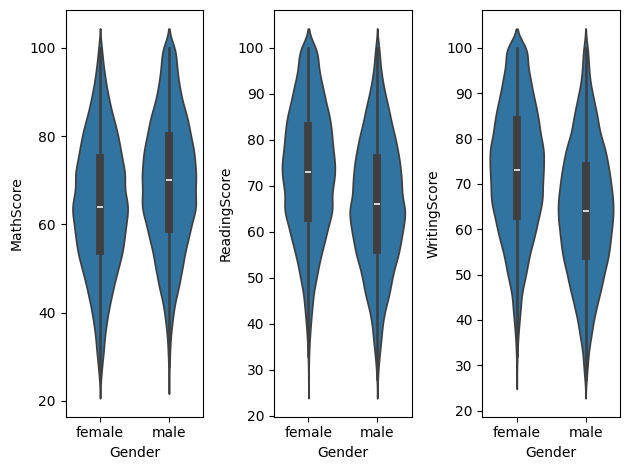

In [64]:
subjects = ['MathScore','ReadingScore','WritingScore']
for i,sub in enumerate(subjects,start=1):
  plt.subplot(1,3,i)
  sns.violinplot(data= df , y=sub , x="Gender" )
plt.tight_layout()

##. Train-Test Split:

In [161]:
from sklearn.model_selection import train_test_split
X = df.drop(['MathScore','ReadingScore','WritingScore'],axis=1)
Y = df[['MathScore','ReadingScore','WritingScore']]

In [162]:
X.head()

,Gender,EthnicGroup,ParentEduc,TestPrep,ParentMaritalStatus,NrSiblings,WklyStudyHours
0,female,group U,bachelor's degree,none,married,3,< 5
2,female,group B,master's degree,none,single,4,< 5
3,male,group A,associate's degree,none,married,1,5 - 10
4,male,group C,some college,none,married,0,5 - 10
5,female,group B,associate's degree,none,married,1,5 - 10


In [163]:
Y.head()

,MathScore,ReadingScore,WritingScore
0,71,71,74
2,87,93,91
3,45,56,42
4,76,78,75
5,73,84,79


In [164]:
x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=0.2)

In [165]:
x_train.shape , x_test.shape

((22896, 7), (5724, 7))

In [166]:
y_train.shape , y_test.shape

((22896, 3), (5724, 3))

###• Check for and handle any categorical features using encoding techniques

In [167]:
binary=['Gender','LunchType','TestPrep','IsFirstChild','TransportMeans']
norminal =['EthnicGroup','ParentEduc','ParentMaritalStatus']
ordinal = {
  'PracticeSport' : ["regularly" , "sometimes" , "never" ],
  'WklyStudyHours' : [ "10" , "5 - 10" , "< 5" ]
}

In [168]:
x_train['WklyStudyHours'].unique()

array(['< 5', '5 - 10', '> 10'], dtype=object)

In [169]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_enc = OrdinalEncoder(categories=[['< 5', '> 10', '5 - 10'] ])

In [170]:
x_train['WklyStudyHours'] = ordinal_enc.fit_transform(x_train[['WklyStudyHours']])
x_test['WklyStudyHours'] = ordinal_enc.transform(x_test[['WklyStudyHours']])

In [171]:
x_train['WklyStudyHours']

,WklyStudyHours
9291,0.0
27898,0.0
26507,2.0
9654,2.0
7232,0.0
...,...
5775,2.0
11397,2.0
14481,2.0
18344,1.0


In [172]:
df['Gender'].unique()[1]

'male'

In [173]:
def binary_encoder(col,df):
  uniques = df[col].unique()
  df[col] = df[col].map({
      uniques[0] : 0 ,
      uniques[1] : 1
      })


In [174]:
binary_encoder('Gender',x_train)

In [175]:
x_train['Gender'].unique()

array([0, 1])

In [176]:
binary_encoder('Gender',x_test)

In [177]:
x_test['Gender'].unique()

array([0, 1])

In [178]:
x_train.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'TestPrep',
       'ParentMaritalStatus', 'NrSiblings', 'WklyStudyHours'],
      dtype='object')

In [179]:
binary=['TestPrep']
for col in binary:
  binary_encoder(col,x_train)
  binary_encoder(col,x_test)



In [180]:
x_test['TestPrep'].unique()

array([0, 1])

In [181]:
x_train['TestPrep'].unique()

array([0, 1])

In [182]:
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder(sparse_output=False)

In [183]:
x_train_encoded = one_hot.fit_transform(x_train[norminal])
x_test_encoded = one_hot.transform(x_test[norminal])

In [185]:
x_train_encoded = pd.DataFrame(
    x_train_encoded,
    columns=one_hot.get_feature_names_out(norminal),
    index=x_train.index
)

x_test_encoded = pd.DataFrame(
    x_test_encoded ,
    columns = one_hot.get_feature_names_out(norminal),
    index=x_test.index
)

In [188]:
x_train_encoded

,EthnicGroup_group A,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,EthnicGroup_group U,ParentEduc_Unknown,ParentEduc_associate's degree,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,ParentEduc_some high school,ParentMaritalStatus_Unknown,ParentMaritalStatus_divorced,ParentMaritalStatus_married,ParentMaritalStatus_single,ParentMaritalStatus_widowed
9291,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
27898,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
26507,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9654,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7232,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5775,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
11397,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14481,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
18344,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [186]:
x_train.drop(columns=norminal ,  inplace=True)
x_test.drop(columns=norminal ,  inplace=True)

In [189]:
x_train = pd.concat([x_train , x_train_encoded],axis=1)
x_test = pd.concat([x_test , x_test_encoded],axis=1)

In [190]:

x_train

,Gender,TestPrep,NrSiblings,WklyStudyHours,EthnicGroup_group A,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,EthnicGroup_group U,...,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,ParentEduc_some high school,ParentMaritalStatus_Unknown,ParentMaritalStatus_divorced,ParentMaritalStatus_married,ParentMaritalStatus_single,ParentMaritalStatus_widowed
9291,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
27898,1,0,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
26507,0,0,2,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9654,0,0,6,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7232,0,1,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5775,0,1,2,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
11397,0,1,2,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14481,1,0,1,2.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
18344,1,0,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [127]:
#I searched how to convert it back to a data frame


##. Feature Scaling:

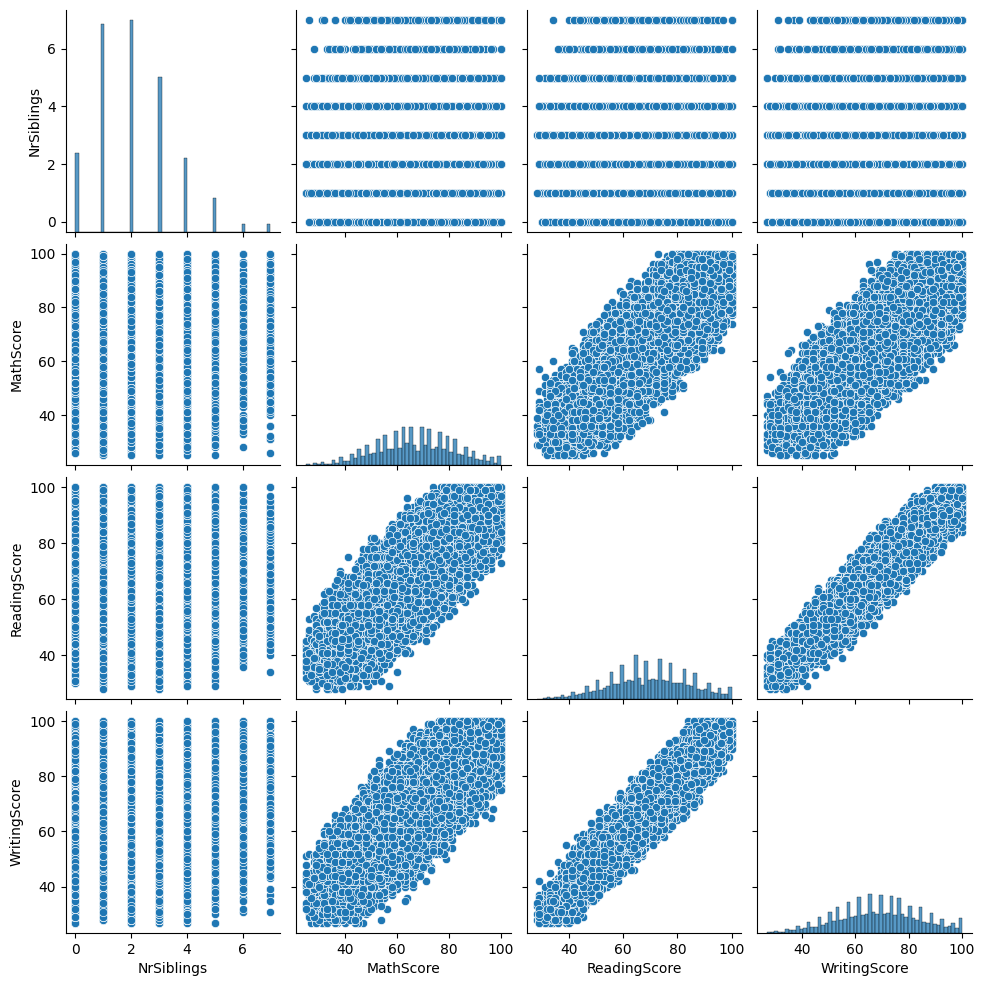

In [192]:
sns.pairplot(df)

<Axes: xlabel='NrSiblings'>

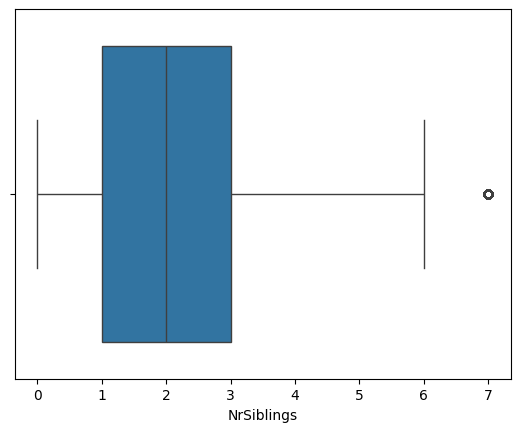

In [194]:
sns.boxplot(data=df , x='NrSiblings')

In [207]:
# even though 7 is an actual value but it is still an oulier, mn max is sensitive to outliers so i am using std
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [209]:
x_train['NrSiblings'] = std_scaler.fit_transform(x_train[['NrSiblings']])
x_test['NrSiblings'] = std_scaler.transform(x_test[['NrSiblings']])

In [210]:
x_train

,Gender,TestPrep,NrSiblings,WklyStudyHours,EthnicGroup_group A,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,EthnicGroup_group U,...,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,ParentEduc_some college,ParentEduc_some high school,ParentMaritalStatus_Unknown,ParentMaritalStatus_divorced,ParentMaritalStatus_married,ParentMaritalStatus_single,ParentMaritalStatus_widowed
9291,0,0,-0.800498,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
27898,1,0,0.603102,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
26507,0,0,-0.098698,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9654,0,0,2.708502,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7232,0,1,-0.098698,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5775,0,1,-0.098698,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
11397,0,1,-0.098698,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14481,1,0,-0.800498,2.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
18344,1,0,-0.098698,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


##. Linear Regression Model:

In [213]:
y_train.columns

Index(['MathScore', 'ReadingScore', 'WritingScore'], dtype='object')

In [211]:
from sklearn.linear_model import LinearRegression
math_model = LinearRegression()
writing_model = LinearRegression()
reding_model = LinearRegression()

In [212]:
math_model.fit(x_train,y_train['MathScore'])

LinearRegression()

In [216]:
reding_model.fit(x_train,y_train['ReadingScore'])

LinearRegression()

In [215]:
writing_model.fit(x_train,y_train['WritingScore'])

LinearRegression()

In [217]:
y_pred_math= math_model.predict(x_test)

In [219]:
y_pred_read= reding_model.predict(x_test)

In [220]:
y_pres_write = writing_model.predict(x_test)

##. Model Evaluation:

In [221]:
from sklearn.metrics import mean_squared_error

In [222]:
mean_squared_error(y_test['MathScore'],y_pred_math)

188.75000490335364

In [223]:
import math
math.sqrt(188.75000490335364)

13.738631842485395

In [225]:
mean_squared_error(y_test['WritingScore'],y_pres_write)

165.3306529307412

In [226]:
math.sqrt(165.3306529307412)

12.858096784934432

In [227]:
mean_squared_error(y_test['ReadingScore'],y_pred_read)

169.80920104666967

In [228]:
math.sqrt(169.80920104666967)

13.031085950398365

##. Visualization

Visualize the predicted values against the actual values using scatter plots or regression plots.

In [ ]:
# I did not know how to use scatter plot to visualise real vs pre so I searched and it was suggested to use 2 scatters eith range(len in X)

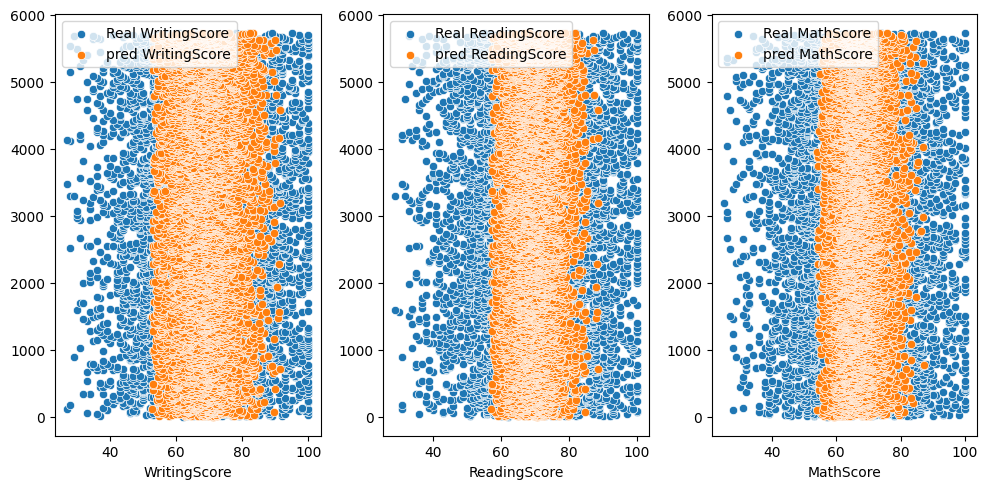

In [243]:
cols = ['WritingScore','ReadingScore','MathScore']
preds = [ y_pres_write , y_pred_read , y_pred_math ]
plt.figure(figsize=(10,5))
i=1
for col,pred in zip(cols,preds):
  plt.subplot(1,3,i)
  sns.scatterplot(x= y_test[col]  , y=range(len(y_test[col])) , label = f"Real {col}" )
  sns.scatterplot(x=pred , y=range(len(pred)), label=f"pred {col}")

  i+=1

plt.tight_layout()
plt.show()

## Conclusion:
• Summarize the findings from the linear regression task.

• Reflect on the model's performance and potential areas for improvement.

In [244]:
"""
1. what I understood from the mse that there is a 30 grades different from the real data and also the
scatter plot shows that the difference is big
2. data processing wise , I do not think we could do any better may be the model, there was no linear relationship
 between the featuures and the targets also most of the features are categorical, so win my opinion we should use
 a model that deals best with categorical data, to ask yes or no questions likke tree based models
"""

'\n1. what I understood from the mse that there is a 30 grades different from the real data and also the \nscatter plot shows that the difference is big \n2. data processing wise , I do not think we could do any better may be the model, there was no linear relationship\n between the featuures and the targets also most of the features are categorical, so win my opinion we should use\n a model that deals best with categorical data, to ask yes or no questions likke tree based models \n'